Week 18 · Day 2 — Tabular Q-Learning
Why this matters

Q-Learning is the foundation of modern reinforcement learning — from playing Atari games to training robots. It teaches an agent to learn which actions lead to long-term rewards, without knowing the environment in advance.

Theory Essentials

Q(s, a): value of taking action a in state s.

Bellman Equation:
Q(s,a)←Q(s,a)+α[r+γmaxa′Q(s′,a′)−Q(s,a)]
where

α: learning rate
γ: discount factor

ε-greedy policy: mostly take the best-known action, sometimes explore.

Goal: learn a Q-table mapping states → actions → values.

When trained well: Q-values approximate the optimal long-term returns.

### 🧭 What it’s really about

You’re teaching an **agent** to learn from experience — not by being told the right move, but by *trying actions, seeing results,* and updating what it believes is “good.”

Over time, it builds a **table of knowledge (the Q-table)** that tells it:

> “If I’m in state `s` and take action `a`, how good is that move in the long run?”

---

### 💡 The core idea

Each cell in the **Q-table** holds an estimate:
`Q(state, action)` = how much *future reward* the agent expects if it takes that action now and behaves well afterward.

Every time the agent acts, it updates this value using the **Bellman equation**, which blends:

* the **immediate reward** it just got, and
* the **best expected future reward** from the next state.

This is how it slowly learns what actions are valuable.

---

### ⚙️ In practice

1. Start with all Q-values = 0 (the agent knows nothing).
2. Explore the world (random actions).
3. After each step, update Q(s, a) using the Bellman formula.
4. Gradually prefer actions with higher Q-values — that’s **ε-greedy policy**:

   * With probability 1–ε → pick the best known move (exploit).
   * With probability ε → try something random (explore).
5. Repeat across many episodes → the Q-table converges toward the *optimal policy*.

---

### 🎮 Why it matters

This is the foundation of modern RL — it’s how agents learned to play Atari, control robots, and make trading decisions.
It’s simple but powerful: **learn by trial and error, remember what worked, and balance exploration vs exploitation.**


Success rate: 6393/10000 = 63.93%
Sample learned policy (argmax a for each state):
[[1 0 0 0]
 [1 0 1 0]
 [2 2 1 0]
 [0 2 2 0]]


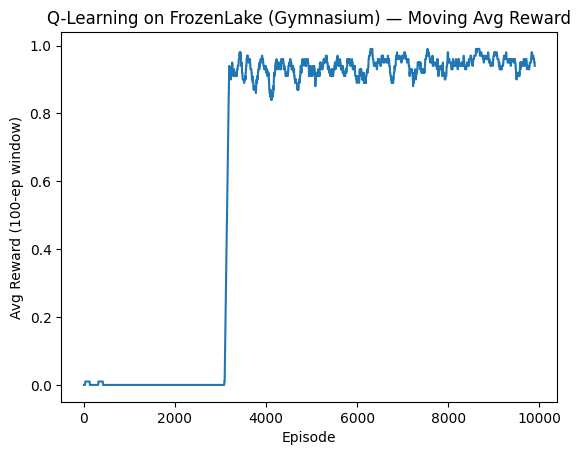

In [9]:
# Q-learning on FrozenLake with Gymnasium + epsilon decay
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym

np.random.seed(42)
env = gym.make("FrozenLake-v1", is_slippery=False)  # deterministic moves
n_states, n_actions = env.observation_space.n, env.action_space.n

Q = np.zeros((n_states, n_actions))

alpha  = 0.8          # higher LR helps propagate sparse rewards
gamma  = 0.99
eps_start, eps_end = 1.0, 0.05
eps_decay = 0.995      # eps <- max(eps_end, eps*eps_decay each episode)
n_episodes = 10000
max_steps  = 100       # safety cap per episode

def epsilon_greedy(state, eps):
    if np.random.rand() < eps:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))

rewards, successes = [], []
eps = eps_start
for ep in range(n_episodes):
    state, info = env.reset(seed=42 if ep == 0 else None)
    total, done = 0.0, False

    for t in range(max_steps):
        action = epsilon_greedy(state, eps)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Bellman update
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

        state = next_state
        total += reward
        if done:
            break

    rewards.append(total)
    successes.append(1 if total > 0 else 0)

    # decay exploration
    eps = max(eps_end, eps * eps_decay)

# Diagnostics
print(f"Success rate: {sum(successes)}/{n_episodes} = {np.mean(successes)*100:.2f}%")
print("Sample learned policy (argmax a for each state):")
print(np.argmax(Q, axis=1).reshape(4,4))  # 0:Left,1:Down,2:Right,3:Up in FrozenLake

# Plot moving average reward
window = 100
ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("Q-Learning on FrozenLake (Gymnasium) — Moving Avg Reward")
plt.xlabel("Episode"); plt.ylabel(f"Avg Reward ({window}-ep window)")
plt.show()



### 🧩 1. Imports and setup

```python
import numpy as np, matplotlib.pyplot as plt, gym
```

✅ Yes — you’ll need to install **gym** (or **gymnasium** if the old one doesn’t work).
Run in your terminal or notebook:

```bash
pip install gym
```

---

### 🌍 2. Environment

```python
env = gym.make("FrozenLake-v1", is_slippery=False)
```

* Creates the **FrozenLake** environment — a 4×4 grid where the agent must reach the goal without falling in holes.
* `is_slippery=False` makes movement deterministic (easier for learning).
* `n_states` = 16 possible tiles, `n_actions` = 4 possible directions.

---

### 🧮 3. Initialize Q-table

```python
Q = np.zeros((n_states, n_actions))
```

* A table of **state × action values**.
* Initially, the agent has no idea which actions are good — all Q-values = 0.

---

### ⚙️ 4. Hyperparameters

```python
alpha = 0.1      # learning rate
gamma = 0.99     # discount factor
epsilon = 0.1    # exploration rate
n_episodes = 500
```

* **α (alpha)** → how strongly to update with new info (learning rate).
* **γ (gamma)** → how much to value *future rewards* vs immediate ones.
* **ε (epsilon)** → how often to *explore randomly* instead of picking the best known action.
* You’ll train for 500 episodes (games).

---

### 🎲 5. Epsilon-greedy policy

```python
def epsilon_greedy(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])
```

* 10% chance → random action (exploration).
* 90% chance → best known action (exploitation).

---

### 🧠 6. Training loop (the learning happens here)

```python
for ep in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = epsilon_greedy(state)
        next_state, reward, done, _, _ = env.step(action)
```

* Start new episode.
* Choose an action.
* Step into the environment → get `next_state` and `reward`.

Then update Q-values using the **Bellman equation**:

```python
Q[state, action] = Q[state, action] + alpha * (
    reward + gamma * np.max(Q[next_state]) - Q[state, action]
)
```

→ the heart of Q-learning:

* Takes current estimate,
* Adds a correction term = learning_rate × (new info − old estimate).

---

### 📈 7. Track performance

```python
plt.plot(np.convolve(rewards, np.ones(20)/20, mode='valid'))
```

* Smooths rewards over 20-episode windows to see progress.
* You should see the curve trend upward — meaning your agent learns to reach the goal more often.

---

### ✅ In short:

This script teaches the agent by **trial and error**:

* It starts clueless, tries moves, sees rewards, and updates its Q-table.
* Over hundreds of episodes, it learns a near-optimal policy: “what’s the best move in each tile.”

---


1) Core (10–15 min)

Task: Print the learned Q-table and interpret what high values mean.

In [10]:
print(Q)


[[0.94148015 0.95099005 0.93206535 0.94148015]
 [0.94148015 0.         0.         0.93057404]
 [0.74565228 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.95099005 0.96059601 0.         0.94148015]
 [0.         0.         0.         0.        ]
 [0.         0.9801     0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.96059601 0.         0.970299   0.95099005]
 [0.96059601 0.97781441 0.9801     0.        ]
 [0.970299   0.99       0.         0.970299  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.95900987 0.98993664 0.970299  ]
 [0.97494467 0.99       1.         0.9801    ]
 [0.         0.         0.         0.        ]]


n_states x n_actions

2) Practice (10–15 min)

Task: Change epsilon to 0.01 and 0.5 to compare exploration effects.

Success rate: 15902/10000 = 79.51%
Sample learned policy (argmax a for each state):
[[1 0 0 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


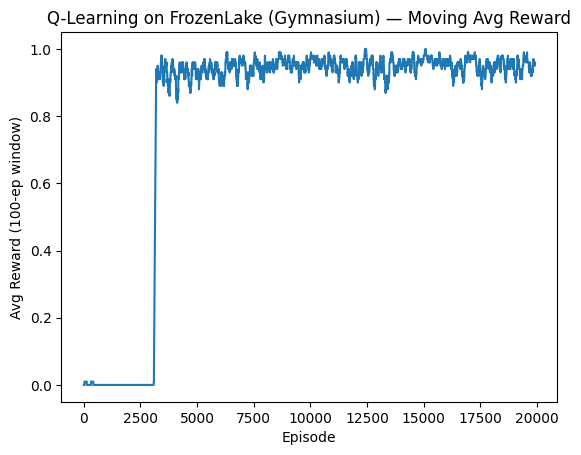

Success rate: 25313/10000 = 84.38%
Sample learned policy (argmax a for each state):
[[1 0 0 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


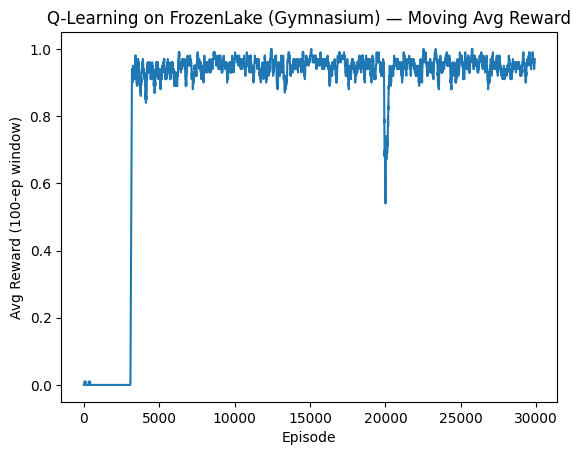

In [11]:
for eps in [0.01, 0.5]:
    # rerun training loop with epsilon=eps
    for ep in range(n_episodes):
        state, info = env.reset(seed=42 if ep == 0 else None)
        total, done = 0.0, False

        for t in range(max_steps):
            action = epsilon_greedy(state, eps)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Bellman update
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

            state = next_state
            total += reward
            if done:
                break

        rewards.append(total)
        successes.append(1 if total > 0 else 0)

        # decay exploration
        eps = max(eps_end, eps * eps_decay)

    # Diagnostics
    print(f"Success rate: {sum(successes)}/{n_episodes} = {np.mean(successes)*100:.2f}%")
    print("Sample learned policy (argmax a for each state):")
    print(np.argmax(Q, axis=1).reshape(4,4))  # 0:Left,1:Down,2:Right,3:Up in FrozenLake

    # Plot moving average reward
    window = 100
    ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
    plt.plot(ma)
    plt.title("Q-Learning on FrozenLake (Gymnasium) — Moving Avg Reward")
    plt.xlabel("Episode"); plt.ylabel(f"Avg Reward ({window}-ep window)")
    plt.show()


Low ε = more exploitation; high ε = more exploration.

3) Stretch (optional, 10–15 min)

Task: Evaluate the trained agent by running 100 test episodes without exploration.

In [12]:
n_eval = 100
success = 0

for _ in range(n_eval):
    s, info = env.reset()
    done = False

    while not done:
        # Always pick the best known action (no exploration)
        a = int(np.argmax(Q[s]))

        s, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        if done and r == 1.0:
            success += 1

print(f"Success rate over {n_eval} test episodes: {success/n_eval:.2f}")


Success rate over 100 test episodes: 1.00


Mini-Challenge (≤40 min) — “Tuning the Explorer”

Goal: Find the best combination of alpha, gamma, and epsilon to maximize success rate on FrozenLake.

Acceptance Criteria:

Try at least 3 parameter sets (e.g., high α vs low α).

Plot reward curves for each configuration.

Report the best-performing combination.

Hint:
Start with α ∈ [0.05, 0.3], γ ∈ [0.8, 0.99], ε ∈ [0.05, 0.3].

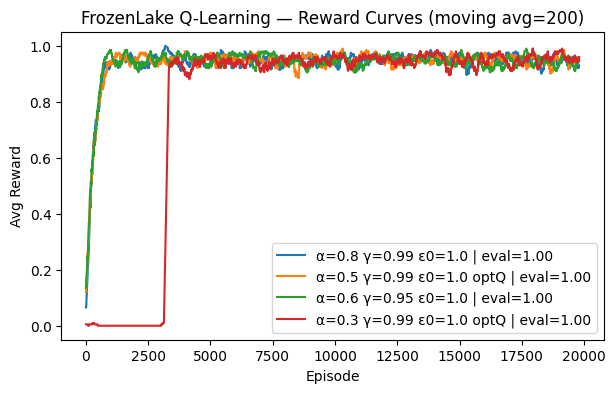

Best configuration: {'alpha': 0.8, 'gamma': 0.99, 'eps_start': 1.0, 'optimistic': False, 'label': 'α=0.8 γ=0.99 ε0=1.0'} → Eval success: 1.00
Greedy policy:
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


In [15]:
# FrozenLake hyperparam sweep (Gymnasium) — stronger exploration + faster learning
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym

np.random.seed(42)
env = gym.make("FrozenLake-v1", is_slippery=False)
nS, nA = env.observation_space.n, env.action_space.n

def train_q(alpha, gamma, eps_start, eps_end=0.05, eps_decay=0.997,
            episodes=20000, max_steps=100, optimistic_init=False):
    Q = (np.ones((nS, nA)) if optimistic_init else np.zeros((nS, nA)))
    rewards = []
    eps = eps_start
    for ep in range(episodes):
        s, _ = env.reset()
        total = 0.0
        for t in range(max_steps):
            # ε-greedy
            if np.random.rand() < eps:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # Bellman update
            Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) - Q[s, a])

            s = ns; total += r
            if done: break
        rewards.append(total)
        eps = max(eps_end, eps * eps_decay)  # decay exploration
    return Q, np.array(rewards)

def moving_avg(x, k=200):
    if len(x) < k: return x
    return np.convolve(x, np.ones(k)/k, mode='valid')

def evaluate(Q, n_eval=300, max_steps=100):
    success = 0
    for _ in range(n_eval):
        s, _ = env.reset()
        for t in range(max_steps):
            a = int(np.argmax(Q[s]))
            s, r, term, trunc, _ = env.step(a)
            if term or trunc:
                if r == 1.0: success += 1
                break
    return success / n_eval

# Try at least 3–4 configs
configs = [
    {"alpha":0.8, "gamma":0.99, "eps_start":1.0, "optimistic":False, "label":"α=0.8 γ=0.99 ε0=1.0"},
    {"alpha":0.5, "gamma":0.99, "eps_start":1.0, "optimistic":True,  "label":"α=0.5 γ=0.99 ε0=1.0 optQ"},
    {"alpha":0.6, "gamma":0.95, "eps_start":1.0, "optimistic":False, "label":"α=0.6 γ=0.95 ε0=1.0"},
    {"alpha":0.3, "gamma":0.99, "eps_start":1.0, "optimistic":True,  "label":"α=0.3 γ=0.99 ε0=1.0 optQ"},
]

results = []
plt.figure(figsize=(7,4))
for cfg in configs:
    Q, rewards = train_q(
        alpha=cfg["alpha"], gamma=cfg["gamma"],
        eps_start=cfg["eps_start"], eps_end=0.05, eps_decay=0.997,
        episodes=20000, optimistic_init=cfg["optimistic"]
    )
    succ = evaluate(Q)
    results.append((succ, cfg, Q, rewards))
    plt.plot(moving_avg(rewards), label=f'{cfg["label"]} | eval={succ:.2f}')
plt.title("FrozenLake Q-Learning — Reward Curves (moving avg=200)")
plt.xlabel("Episode"); plt.ylabel("Avg Reward"); plt.legend(); plt.show()

best = max(results, key=lambda x: x[0])
best_succ, best_cfg, best_Q, _ = best
print("Best configuration:", best_cfg, f"→ Eval success: {best_succ:.2f}")

# Pretty-print greedy policy
arrows = {0:'←',1:'↓',2:'→',3:'↑'}
policy = np.argmax(best_Q, axis=1).reshape(4,4)
print("Greedy policy:\n" + '\n'.join(' '.join(arrows[a] for a in row) for row in policy))


Notes / Key Takeaways

Q-Learning is off-policy — it learns optimal behavior even from random exploration.

Learning rate (α) controls how quickly knowledge updates.

Discount (γ) determines how much future rewards matter.

Exploration (ε) prevents the agent from getting stuck.

Convergence happens when updates stabilize across episodes.

Reflection

What happens if ε = 0 (no exploration)?

How does Q-Learning “learn” even without labeled data?

1. What happens if ε = 0 (no exploration)?
If ε = 0, the agent never explores — it always picks the action it currently thinks is best.
But early in training, all Q-values start the same (usually 0), so the agent keeps repeating the same moves and never discovers better paths. Learning gets stuck in a poor or random policy because it never tries new actions that could lead to higher rewards.

2. How does Q-Learning “learn” even without labeled data?
Q-learning doesn’t need labeled examples — it learns from experience.
Each action gives feedback (a reward and the next state), and the agent updates its estimates of how good that action was using the Bellman equation. Over many trials, these self-generated experiences teach it which actions lead to higher long-term rewards — effectively labeling the data through interaction.